# F1 Pit Stop 예측 — LSTM 실험 (범주형 임베딩 포함)

수업 LSTM 레시피를 이진 분류용으로 확장하여 과거 N랩 시퀀스로 다음 랩 피트 여부(`PitNextLap`)를 예측한다.
수치형 전용 구조에 **범주형(Driver/Compound/Race)을 Embedding으로 시퀀스에 결합**한다.

- 구조: `[연속형 + 범주형 Embedding] → LSTM(128) → LSTM(128) → Dropout(0.1) → Dense(1, sigmoid)`
- HPO: `{epochs, batch_size}` grid search (수업 탐색공간 동일)
- 학습 종료: `EarlyStopping(monitor='val_loss', patience=epoch*0.3)`
- 검증: **GroupKFold(Race+Year) 5-fold** (누수 방지·공정 비교)
- 평가: ROC-AUC (보조 F1 / confusion matrix)

상세 설계: `C289039_유승환_LSTM_실험계획.md`

## 0. import & 설정

In [10]:
import time
from itertools import product
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Embedding, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===== 실험 설정 =====
WINDOW_SIZE  = 5         # 기본 윈도우 (sensitivity: 3 / 5 / 10)
USE_SCALER   = True      # 연속형 StandardScaler (train fold로만 fit)
POS_WEIGHT   = 4.03      # 클래스 불균형 대응 (neg/pos)
CLASS_WEIGHT = {0: 1.0, 1: POS_WEIGHT}
EMB_DIMS     = {'Driver': 16, 'Compound': 3, 'Race': 6}   # 범주형 임베딩 차원
print('TF', tf.__version__)

TF 2.21.0


## 1. 데이터 로드 & 정렬 (Step 1)

슬라이딩 윈도우는 '과거→현재' 순서를 전제로 하므로 (Driver, Race, Year, LapNumber)로 정렬한다.
범주형 인코딩을 위해 test도 함께 로드한다.

In [11]:
train = pd.read_csv('../data/kaggle_data/train.csv')
test  = pd.read_csv('../data/kaggle_data/test.csv')

cont_features = ['LapNumber', 'TyreLife', 'LapTime (s)', 'LapTime_Delta',
                 'Cumulative_Degradation', 'RaceProgress', 'Position', 'Position_Change']
cat_features  = ['Driver', 'Compound', 'Race']
group_keys    = ['Driver', 'Race', 'Year']
target_col    = 'PitNextLap'

# Step1 정렬: 각 (Driver, Race, Year) 블록을 LapNumber 오름차순으로
train = train.sort_values(['Driver', 'Race', 'Year', 'LapNumber']).reset_index(drop=True)

print('train :', train.shape, '| test :', test.shape)
print('positive rate :', round(train[target_col].mean(), 4))
train[cat_features + cont_features + [target_col]].head()

train : (439140, 16) | test : (188165, 15)
positive rate : 0.199


,Driver,Compound,Race,LapNumber,TyreLife,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position,Position_Change,PitNextLap
0,ALB,MEDIUM,Abu Dhabi Grand Prix,1,1.0,116.433,0.000,0.000,0.013889,19,0.0,0.0
1,ALB,HARD,Abu Dhabi Grand Prix,18,7.0,90.053,-9.676,-5.920,0.250000,16,2.0,1.0
2,ALB,MEDIUM,Abu Dhabi Grand Prix,61,27.0,88.064,5.716,-44.931,0.847222,15,1.0,0.0
3,ALB,MEDIUM,Abu Dhabi Grand Prix,1,9.0,92.984,0.000,0.000,0.017241,18,0.0,0.0
4,ALB,MEDIUM,Abu Dhabi Grand Prix,5,10.0,90.723,-1.354,-8.729,0.086207,14,-1.0,0.0


## 2. 범주형 인코딩 — LabelEncoder (Step 2)

Driver/Compound/Race를 임베딩 입력용 **정수 코드**로 변환한다.
**train+test를 합쳐 fit**하여 test에만 있는 카테고리(unseen) 에러를 방지한다(라벨 번호만 부여하므로 누수 아님).
각 피처의 고윳값 수(`cat_dims`)를 임베딩 `input_dim`으로 쓴다.

In [12]:
encoders, cat_dims = {}, []
for col in cat_features:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]], axis=0).astype(str))   # train+test 합쳐 fit
    train[col + '_enc'] = le.transform(train[col].astype(str))
    test[col + '_enc']  = le.transform(test[col].astype(str))
    encoders[col] = le
    cat_dims.append(len(le.classes_))

cat_enc  = [c + '_enc' for c in cat_features]
emb_dims = [EMB_DIMS[c] for c in cat_features]            # [16, 3, 6]
print('cat_dims (임베딩 input_dim):', dict(zip(cat_features, cat_dims)))
print('emb_dims (임베딩 output_dim):', dict(zip(cat_features, emb_dims)))

cat_dims (임베딩 input_dim): {'Driver': 887, 'Compound': 5, 'Race': 26}
emb_dims (임베딩 output_dim): {'Driver': 16, 'Compound': 3, 'Race': 6}


## 3. 슬라이딩 윈도우 구성 (Step 4)

각 샘플이 **과거 정보만** 담도록 하여 샘플 내부 미래 누수를 구조적으로 차단한다.
연속형 `Xn`(N, ws, 8)과 범주형 코드 `Xc`(N, ws, 3)를 분리 수집하고, `groups`는 GroupKFold용 Race+Year 식별자다.

> 연속형 스케일링(Step 3)은 검증 누수 방지를 위해 fold 내부(`run_oof`)에서 train 부분으로만 fit한다.

In [13]:
def make_sliding_windows(df, group_keys, cont_cols, cat_cols, target_col, window_size=5):
    Xn_list, Xc_list, y_list, grp_list = [], [], [], []
    for keys, g in df.groupby(group_keys):
        g = g.sort_values('LapNumber')
        cont = g[cont_cols].values
        cat  = g[cat_cols].values
        tgt  = g[target_col].values
        race_year = f'{keys[1]}_{keys[2]}'              # Race_Year (GroupKFold 키)
        for i in range(window_size, len(g)):
            Xn_list.append(cont[i-window_size:i])       # 과거 ws랩 연속형
            Xc_list.append(cat[i-window_size:i])        # 과거 ws랩 범주형 코드
            y_list.append(tgt[i])                        # 현재 랩의 PitNextLap
            grp_list.append(race_year)
    return (np.array(Xn_list, dtype='float32'),
            np.array(Xc_list, dtype='int32'),
            np.array(y_list, dtype='float32'),
            np.array(grp_list))

In [14]:
Xn, Xc, y, groups = make_sliding_windows(
    train, group_keys, cont_features, cat_enc, target_col, WINDOW_SIZE)
print('Xn :', Xn.shape, '| Xc :', Xc.shape, '| y :', y.shape,
      '| pos rate :', round(float(y.mean()), 4))

Xn : (263412, 5, 8) | Xc : (263412, 5, 3) | y : (263412,) | pos rate : 0.2613


## 4. 모델 — 범주형 Embedding + LSTM (Step 6)

Keras 함수형 API(다중 입력). 각 타임스텝 범주형 코드를 `Embedding`으로 밀집 벡터화하여 연속형과 마지막 축으로 `Concatenate` 후 LSTM에 통과시킨다.
임베딩 차원: Driver=16, Compound=3, Race=6. 분류 전환: 출력 sigmoid, loss BCE, metric AUC.

In [15]:
def build_lstm(window_size, n_cont, cat_dims, emb_dims, dropout=0.1):
    cont_in = Input(shape=(window_size, n_cont), name='cont')
    cat_inputs, emb_layers = [], []
    for col, card, dim in zip(['Driver', 'Compound', 'Race'], cat_dims, emb_dims):
        ci = Input(shape=(window_size,), dtype='int32', name=f'{col}_in')
        e  = Embedding(input_dim=card, output_dim=dim, name=f'{col}_emb')(ci)   # (ws, dim)
        cat_inputs.append(ci)
        emb_layers.append(e)
    x = Concatenate(axis=-1)([cont_in] + emb_layers)     # (ws, n_cont + sum(emb))
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(128)(x)
    x = Dropout(dropout)(x)                               # 수업: Dropout(0.1)
    out = Dense(1, activation='sigmoid')(x)               # 분류 sigmoid
    model = Model(inputs=[cont_in] + cat_inputs, outputs=out, name='PitStop_LSTM_emb')
    model.compile(loss='binary_crossentropy',             # 분류 BCE
                  optimizer=Adam(learning_rate=0.001),
                  metrics=[tf.keras.metrics.AUC(name='auc')])
    return model

def to_inputs(Xn, Xc):
    # 모델 입력 순서: [연속형, Driver, Compound, Race]
    return [Xn] + [Xc[:, :, j] for j in range(Xc.shape[2])]

build_lstm(WINDOW_SIZE, len(cont_features), cat_dims, emb_dims).summary()

Model: "PitStop_LSTM_emb"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Driver_in           │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Compound_in         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Race_in             │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont (InputLayer)   │ (None, 5, 8)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Driver_emb          │ (None, 5, 16)     │     14,192 │ Driver_in[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Compound_emb        │ (None, 5, 3)      │         15 │ Compound_in[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Race_emb            │ (None, 5, 6)      │        156 │ Race_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 5, 33)     │          0 │ cont[0][0],       │
│ (Concatenate)       │                   │            │ Driver_emb[0][0], │
│                     │                   │            │ Compound_emb[0][… │
│                     │                   │            │ Race_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_50 (LSTM)      │ (None, 5, 128)    │     82,944 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_51 (LSTM)      │ (None, 128)       │    131,584 │ lstm_50[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 128)       │          0 │ lstm_51[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 1)         │        129 │ dropout_25[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 229,020 (894.61 KB)

 Trainable params: 229,020 (894.61 KB)

 Non-trainable params: 0 (0.00 B)

## 5. GroupKFold OOF 평가 함수 (Step 3·5·7)

같은 레이스(Race+Year)는 한 fold에만 배치하여 누수 없이 평가(Step 5)한다.
연속형 `StandardScaler`는 train fold로만 fit(Step 3), 학습은 `class_weight`+`EarlyStopping`(Step 7).

In [16]:
def run_oof(Xn, Xc, y, groups, window_size, cat_dims, emb_dims, epochs, batch_size,
            dropout=0.1, use_scaler=True, n_splits=5, verbose=0):
    gkf = GroupKFold(n_splits=n_splits)
    oof = np.zeros(len(Xn))
    fold_aucs = []
    for f, (tr, va) in enumerate(gkf.split(Xn, y, groups=groups)):
        Xn_tr, Xn_va = Xn[tr], Xn[va]
        if use_scaler:                                   # Step3: train fold로만 fit
            sc = StandardScaler()
            n, w, feat = Xn_tr.shape
            Xn_tr = sc.fit_transform(Xn_tr.reshape(-1, feat)).reshape(n, w, feat).astype('float32')
            Xn_va = sc.transform(Xn_va.reshape(-1, feat)).reshape(Xn_va.shape).astype('float32')
        m = build_lstm(window_size, Xn.shape[2], cat_dims, emb_dims, dropout)
        es = EarlyStopping(monitor='val_loss', mode='min',
                           patience=max(1, int(epochs * 0.3)),
                           restore_best_weights=True)
        m.fit(to_inputs(Xn_tr, Xc[tr]), y[tr],
              validation_data=(to_inputs(Xn_va, Xc[va]), y[va]),
              epochs=epochs, batch_size=batch_size,
              class_weight=CLASS_WEIGHT, callbacks=[es], verbose=verbose)
        p = m.predict(to_inputs(Xn_va, Xc[va]), verbose=0).ravel()
        oof[va] = p
        a = roc_auc_score(y[va], p)
        fold_aucs.append(a)
        print(f'  fold {f}  AUC = {a:.4f}')
    oof_auc = roc_auc_score(y, oof)
    print(f'>>> OOF AUC = {oof_auc:.4f} | mean {np.mean(fold_aucs):.4f} | std {np.std(fold_aucs):.4f}')
    return oof, fold_aucs

## 6. HPO — {epochs, batch_size} grid search (Step 8)

> 수업은 `scikeras` + `GridSearchCV`를 썼으나, 현재 환경의 `scikeras 0.13`은 `sklearn 1.8`과
> 비호환이라 **동일한 탐색공간**(`epochs`, `batch_size`)을 GroupKFold + ROC-AUC 기준으로
> **수동 grid search**로 구현한다(목적·로직 동일).

계산량을 줄이기 위해 **표본 일부(최대 4만)**로 베스트 조합을 탐색한다.

In [17]:
param_grid = {'epochs': [20, 40], 'batch_size': [16, 32]}   # 수업과 동일한 탐색 공간

rng  = np.random.default_rng(SEED)
samp = rng.choice(len(Xn), size=min(40000, len(Xn)), replace=False)
Xn_s, Xc_s, ys, gs = Xn[samp], Xc[samp], y[samp], groups[samp]

results = []
for ep, bs in product(param_grid['epochs'], param_grid['batch_size']):
    print(f'[grid] epochs={ep}, batch_size={bs}')
    oof_s, _ = run_oof(Xn_s, Xc_s, ys, gs, WINDOW_SIZE, cat_dims, emb_dims, ep, bs,
                       use_scaler=USE_SCALER, n_splits=2, verbose=0)
    results.append({'epochs': ep, 'batch_size': bs, 'auc': round(roc_auc_score(ys, oof_s), 4)})

hpo_df = pd.DataFrame(results).sort_values('auc', ascending=False).reset_index(drop=True)
best_epochs = int(hpo_df.loc[0, 'epochs'])
best_bs     = int(hpo_df.loc[0, 'batch_size'])
print('best params :', {'epochs': best_epochs, 'batch_size': best_bs})
hpo_df

[grid] epochs=20, batch_size=16
  fold 0  AUC = 0.7468
  fold 1  AUC = 0.7564
>>> OOF AUC = 0.7521 | mean 0.7516 | std 0.0048
[grid] epochs=20, batch_size=32
  fold 0  AUC = 0.7380
  fold 1  AUC = 0.7409
>>> OOF AUC = 0.7382 | mean 0.7394 | std 0.0015
[grid] epochs=40, batch_size=16
  fold 0  AUC = 0.7501
  fold 1  AUC = 0.7562
>>> OOF AUC = 0.7534 | mean 0.7531 | std 0.0031
[grid] epochs=40, batch_size=32
  fold 0  AUC = 0.7375
  fold 1  AUC = 0.7447
>>> OOF AUC = 0.7408 | mean 0.7411 | std 0.0036
best params : {'epochs': 40, 'batch_size': 16}


,epochs,batch_size,auc
0,40,16,0.7534
1,20,16,0.7521
2,40,32,0.7408
3,20,32,0.7382


## 7. GroupKFold 5-fold OOF 평가 — 최종 성능 (Step 9)

In [18]:
t0 = time.time()
oof5, aucs5 = run_oof(Xn, Xc, y, groups, WINDOW_SIZE, cat_dims, emb_dims,
                      best_epochs, best_bs, dropout=0.1, use_scaler=USE_SCALER,
                      n_splits=5, verbose=1)
print('elapsed (s):', round(time.time() - t0, 1))

Epoch 1/40
13165/13165 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - auc: 0.8472 - loss: 0.8249 - val_auc: 0.8089 - val_loss: 0.5509
Epoch 2/40
13165/13165 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - auc: 0.8644 - loss: 0.7795 - val_auc: 0.8082 - val_loss: 0.5515
Epoch 3/40
13165/13165 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - auc: 0.8709 - loss: 0.7622 - val_auc: 0.8040 - val_loss: 0.5667
Epoch 4/40
13165/13165 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - auc: 0.8760 - loss: 0.7480 - val_auc: 0.7973 - val_loss: 0.5742
Epoch 5/40
13165/13165 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - auc: 0.8814 - loss: 0.7323 - val_auc: 0.7915 - val_loss: 0.5831
Epoch 6/40
13165/13165 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - auc: 0.8878 - loss: 0.7125 - val_auc: 0.7947 - val_loss: 0.5758
Epoch 7/40
13165/13165 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - auc: 0.8952 - loss: 0.6888 - val_auc: 0.7876 - val_loss: 0.5940
Epoch 8/40
13165/13165 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - auc: 0.9033 - loss: 0.6618 - val_auc: 0.7826 - val_loss: 0.6047
Epoch 9/40
13165

## 8. window_size 민감도 분석 (3 / 5 / 10) (Step 10)

'피트 징후가 몇 랩 전부터 나타나는가'를 데이터로 검증. window=10은 짧은 레이스 표본이 줄어듦에 주의.

In [19]:
sens = {}
for ws in [3, 5, 10]:
    Xnw, Xcw, yw, gw = make_sliding_windows(
        train, group_keys, cont_features, cat_enc, target_col, ws)
    print(f'window_size={ws}  samples={len(Xnw)}')
    oofw, _ = run_oof(Xnw, Xcw, yw, gw, ws, cat_dims, emb_dims, best_epochs, best_bs,
                      use_scaler=USE_SCALER, n_splits=5, verbose=0)
    sens[ws] = round(roc_auc_score(yw, oofw), 4)
print('window_size sensitivity :', sens)

window_size=3  samples=327025
  fold 0  AUC = 0.7589
  fold 1  AUC = 0.8325
  fold 2  AUC = 0.7519
  fold 3  AUC = 0.7919
  fold 4  AUC = 0.7755
>>> OOF AUC = 0.7771 | mean 0.7821 | std 0.0288
window_size=5  samples=263412
  fold 0  AUC = 0.8094
  fold 1  AUC = 0.7578
  fold 2  AUC = 0.7655
  fold 3  AUC = 0.7737
  fold 4  AUC = 0.7399
>>> OOF AUC = 0.7734 | mean 0.7693 | std 0.0229
window_size=10  samples=128811
  fold 0  AUC = 0.8260
  fold 1  AUC = 0.7259
  fold 2  AUC = 0.8404
  fold 3  AUC = 0.7936
  fold 4  AUC = 0.7564
>>> OOF AUC = 0.7823 | mean 0.7885 | std 0.0426
window_size sensitivity : {3: 0.7771, 5: 0.7734, 10: 0.7823}


## 9. 평가 지표 — F1 / Confusion Matrix / ROC (Step 11)

OOF AUC : 0.7735
F1      : 0.5595
Confusion Matrix:
[[117492  77096]
 [ 12148  56676]]


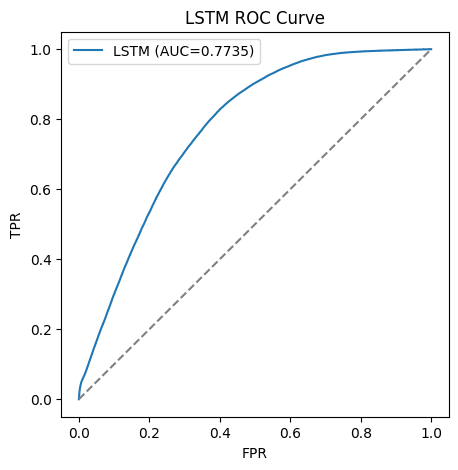

In [20]:
pred_label = (oof5 >= 0.5).astype(int)
print('OOF AUC :', round(roc_auc_score(y, oof5), 4))
print('F1      :', round(f1_score(y, pred_label), 4))
print('Confusion Matrix:')
print(confusion_matrix(y, pred_label))

fpr, tpr, _ = roc_curve(y, oof5)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'LSTM (AUC={roc_auc_score(y, oof5):.4f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('LSTM ROC Curve'); plt.legend()
plt.show()

## 10. 전체 재학습 → test 예측 → submission (Step 12)

test의 각 행은 같은 그룹 내 직전 랩들로 윈도우를 만든다.
초반 랩(과거 < window_size)은 첫 랩으로 **left-pad**하여 모든 id에 예측을 부여한다.

In [21]:
def make_predict_windows(df, group_keys, cont_cols, cat_cols, window_size):
    ids, Xn_list, Xc_list = [], [], []
    for keys, g in df.groupby(group_keys):
        g = g.sort_values('LapNumber')
        cont = g[cont_cols].values
        cat  = g[cat_cols].values
        idv  = g['id'].values
        for i in range(len(g)):
            wn = cont[max(0, i - window_size):i]
            wc = cat[max(0, i - window_size):i]
            if len(wn) < window_size:                    # left-pad: 첫 랩 반복
                pad_n = np.repeat(cont[0:1], window_size - len(wn), axis=0)
                pad_c = np.repeat(cat[0:1],  window_size - len(wc), axis=0)
                wn = np.vstack([pad_n, wn]) if len(wn) > 0 else pad_n
                wc = np.vstack([pad_c, wc]) if len(wc) > 0 else pad_c
            ids.append(idv[i]); Xn_list.append(wn); Xc_list.append(wc)
    return (np.array(ids),
            np.array(Xn_list, dtype='float32'),
            np.array(Xc_list, dtype='int32'))

In [22]:
# 전체 train으로 최종 모델 재학습 (best epoch/batch)
scaler, Xn_all = None, Xn
if USE_SCALER:
    scaler = StandardScaler()
    n, w, feat = Xn.shape
    Xn_all = scaler.fit_transform(Xn.reshape(-1, feat)).reshape(Xn.shape).astype('float32')

final = build_lstm(WINDOW_SIZE, Xn.shape[2], cat_dims, emb_dims, 0.1)
final.fit(to_inputs(Xn_all, Xc), y, epochs=best_epochs, batch_size=best_bs,
          class_weight=CLASS_WEIGHT, verbose=1)
final.save('best_lstm.keras')
print('saved best_lstm.keras')

Epoch 1/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - auc: 0.8452 - loss: 0.8245
Epoch 2/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - auc: 0.8615 - loss: 0.7814
Epoch 3/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - auc: 0.8681 - loss: 0.7647
Epoch 4/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - auc: 0.8732 - loss: 0.7508
Epoch 5/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - auc: 0.8783 - loss: 0.7361
Epoch 6/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - auc: 0.8842 - loss: 0.7188
Epoch 7/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - auc: 0.8909 - loss: 0.6963
Epoch 8/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - auc: 0.8985 - loss: 0.6710
Epoch 9/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - auc: 0.9058 - loss: 0.6444
Epoch 10/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - auc: 0.9131 - loss: 0.6169
Epoch 11/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - auc: 0.9193 - loss: 0.5929
Epoch 12/40
16464/16464 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms

In [23]:
ids_test, Xn_test, Xc_test = make_predict_windows(
    test, group_keys, cont_features, cat_enc, WINDOW_SIZE)
if scaler is not None:
    nt, wt, ft = Xn_test.shape
    Xn_test = scaler.transform(Xn_test.reshape(-1, ft)).reshape(Xn_test.shape).astype('float32')

proba = final.predict(to_inputs(Xn_test, Xc_test), verbose=1).ravel()
sub = pd.DataFrame({'id': ids_test, 'PitNextLap': proba})
sub = sub.set_index('id').loc[test['id']].reset_index()   # 원본 test 순서로 정렬
sub.to_csv('submission_lstm.csv', index=False)
print(sub.shape); sub.head()

5881/5881 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
(188165, 2)


,id,PitNextLap
0,439140,4.736839e-06
1,439141,1.094780e-04
2,439142,6.535360e-08
3,439143,4.664214e-01
4,439144,9.127995e-01


## 11. 결과 기록

| 항목 | 값 |
|------|-----|
| OOF AUC (window=5) | |
| Fold std | |
| F1 (thr=0.5) | |
| window sensitivity (3/5/10) | |
| best {epochs, batch_size} | |
| 범주형 임베딩 효용 (vs 수치형 전용) | |